# 02. MATPOWER/PYPOWER 코드로 보는 Newton-Raphson

**목표**
- Newton-Raphson이 실제 코드에서 어떤 배열을 만들고 갱신하는지 확인한다.
- MATPOWER/PYPOWER 계열의 공통 흐름을 `case9`에서 한 번 직접 따라간다.
- 이후 benchmark에서 나오는 `Jacobian`, `linear solve`, `update`라는 말을 코드와 연결한다.

**대조한 기준 코드**
- MATPOWER `/opt/matpower/lib/newtonpf.m`: polar Newton loop
- MATPOWER `/opt/matpower/lib/dSbus_dV.m`: `dS/dVa`, `dS/dVm` derivative
- pandapower `pandapower.pypower.newtonpf.py`: PYPOWER-derived Newton loop
- pandapower `pandapower.pypower.dSbus_dV.py`: Python/SciPy sparse derivative

**이 노트북의 범위**
- 실제 구현의 FACTS, TDPF, distributed slack, 옵션 분기는 제외한다.
- 공통 뼈대인 mismatch 구성, Jacobian block slicing, sparse solve, voltage update만 남긴다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import inspect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.sparse import hstack, vstack
from scipy.sparse.linalg import spsolve
from pandapower.pypower.dSbus_dV import dSbus_dV
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 140)


In [2]:
source_refs = pd.DataFrame([
    {
        'source': 'MATPOWER newtonpf.m',
        'local path': '/opt/matpower/lib/newtonpf.m',
        'relevant part': 'initialize V/Va/Vm, form F, build J blocks, solve dx, update Va/Vm',
    },
    {
        'source': 'MATPOWER dSbus_dV.m',
        'local path': '/opt/matpower/lib/dSbus_dV.m',
        'relevant part': 'Ibus=Ybus*V, dS/dVa, dS/dVm formula in polar coordinates',
    },
    {
        'source': 'pandapower.pypower.newtonpf.py',
        'local path': inspect.getfile(__import__('pandapower.pypower.newtonpf', fromlist=['*'])),
        'relevant part': 'create_jacobian_matrix, scipy.sparse.linalg.spsolve, Va/Vm update',
    },
    {
        'source': 'pandapower.pypower.dSbus_dV.py',
        'local path': inspect.getfile(__import__('pandapower.pypower.dSbus_dV', fromlist=['*'])),
        'relevant part': 'sparse diagV/diagIbus/diagVnorm and derivative matrices',
    },
])
display(source_refs)


,source,local path,relevant part
0,MATPOWER newtonpf.m,/opt/matpower/lib/newtonpf.m,"initialize V/Va/Vm, form F, build J blocks, solve dx, update Va/Vm"
1,MATPOWER dSbus_dV.m,/opt/matpower/lib/dSbus_dV.m,"Ibus=Ybus*V, dS/dVa, dS/dVm formula in polar coordinates"
2,pandapower.pypower.newtonpf.py,/usr/local/lib/python3.10/dist-packages/pandapower/pypower/newtonpf.py,"create_jacobian_matrix, scipy.sparse.linalg.spsolve, Va/Vm update"
3,pandapower.pypower.dSbus_dV.py,/usr/local/lib/python3.10/dist-packages/pandapower/pypower/dSbus_dV.py,sparse diagV/diagIbus/diagVnorm and derivative matrices


**Newton loop의 순서**
1. `V0`에서 전압 각도 `Va`와 크기 `Vm`을 분리한다.
2. PV/PQ bus 규칙에 맞춰 reduced mismatch `F`를 만든다.
3. `dSbus_dV(Ybus, V)`로 full derivative를 만든다.
4. 필요한 행/열만 잘라 `J11`, `J12`, `J21`, `J22` block을 만든다.
5. sparse linear system `J dx = -F`를 푼다.
6. `dx`를 `Va(PV,PQ)`, `Vm(PQ)`에 나눠 더한다.
7. 새 `V = Vm * exp(j Va)`에서 mismatch를 다시 계산한다.

**Complex power 계산**
$$
I_{bus} = Y_{bus}V, \qquad S_{calc}(V) = diag(V)\overline{I_{bus}}
$$

**Residual 부호**
$$
mis(V) = S_{calc}(V) - S_{spec}
$$

**Reduced mismatch와 state vector**
$$
F(x) =
\begin{bmatrix}
\Re(mis_{PV}) \\
\Re(mis_{PQ}) \\
\Im(mis_{PQ})
\end{bmatrix}, \qquad
x =
\begin{bmatrix}
V_a(PV) \\
V_a(PQ) \\
V_m(PQ)
\end{bmatrix}
$$

**Newton update**
$$
J(x_k)\,dx = -F(x_k), \qquad x_{k+1}=x_k+dx
$$

**아래 코드에서 볼 것**
- 수식의 각 단계가 코드 주석과 같은 순서로 배치되어 있다.
- `dSbus_dV` 다음에 block slicing이 나오고, 그 다음 `spsolve(J, -F)`가 나온다.


In [3]:
def reduced_mismatch(case, V):
    """MATPOWER newtonpf.m의 F 구성과 같은 reduced mismatch를 만든다.

    MATPOWER는 mis = V * conj(Ybus * V) - Sbus(Vm)을 만든 뒤,
    P mismatch는 PV+PQ bus에서, Q mismatch는 PQ bus에서만 가져온다.
    Slack bus는 기준 bus라 reduced Newton system에서 빠진다.
    """
    mis = V * np.conj(case.ybus @ V) - case.sbus
    return np.r_[mis[case.pv].real, mis[case.pq].real, mis[case.pq].imag]


def reduced_jacobian_from_dSbus_dV(case, V):
    """dSbus_dV 결과를 Newton system의 4-block Jacobian으로 자른다.

    dSbus_dV는 모든 bus에 대한 full derivative를 준다.
    Newton state는 Va(PV,PQ), Vm(PQ)이므로 필요한 행/열만 선택한다.
    """
    pvpq = np.r_[case.pv, case.pq]

    # pandapower의 dSbus_dV는 (dS/dVm, dS/dVa) 순서로 반환한다.
    # MATPOWER 문서/최신 newtonpf.m에서는 이름을 dSbus_dVa, dSbus_dVm으로 맞춰 쓴다.
    dS_dVm, dS_dVa = dSbus_dV(case.ybus, V)

    # P equation rows: PV+PQ. Q equation rows: PQ only.
    # Angle columns: PV+PQ. Magnitude columns: PQ only.
    j11 = dS_dVa[np.ix_(pvpq, pvpq)].real
    j12 = dS_dVm[np.ix_(pvpq, case.pq)].real
    j21 = dS_dVa[np.ix_(case.pq, pvpq)].imag
    j22 = dS_dVm[np.ix_(case.pq, case.pq)].imag

    return vstack([hstack([j11, j12]), hstack([j21, j22])], format='csr')


def educational_newton_pf(case, tol=1e-8, max_it=20):
    """MATPOWER/PYPOWER 스타일 polar Newton-Raphson을 간소화한 구현.

    의도적으로 기능을 줄였다.
    - voltage-dependent load, distributed slack, FACTS, TDPF는 제외한다.
    - 목적은 성능이 아니라 알고리즘의 배열 흐름을 드러내는 것이다.
    """
    V = case.v0.astype(np.complex128, copy=True)
    Va = np.angle(V)
    Vm = np.abs(V)

    npv = len(case.pv)
    npq = len(case.pq)
    pvpq = np.r_[case.pv, case.pq]

    rows = []
    for iteration in range(max_it + 1):
        # 1. 현재 전압에서 mismatch F를 평가한다.
        F = reduced_mismatch(case, V)
        normF = np.linalg.norm(F, np.inf) if F.size else 0.0
        rows.append({'iteration': iteration, 'mismatch_inf_norm': normF})

        # 2. tolerance 안에 들어오면 더 이상 선형화하지 않는다.
        if normF < tol:
            return V, pd.DataFrame(rows), True
        if iteration == max_it:
            break

        # 3. 현재 V에서 Jacobian을 만든다. Newton은 매 iteration 새 J를 쓴다.
        J = reduced_jacobian_from_dSbus_dV(case, V)

        # 4. 선형화된 보정량을 푼다. MATPOWER의 mplinsolve, pandapower의 spsolve에 해당한다.
        dx = -np.asarray(spsolve(J, F)).reshape(-1)

        # 5. dx를 상태 벡터 정의와 같은 순서로 다시 전압 변수에 나눠 더한다.
        if npv:
            Va[case.pv] += dx[0:npv]
        if npq:
            Va[case.pq] += dx[npv:npv + npq]
            Vm[case.pq] += dx[npv + npq:npv + 2 * npq]

        # 6. polar 변수 Va/Vm을 다시 complex voltage V로 조립한다.
        V = Vm * np.exp(1j * Va)

        # 7. 음수 Vm 등으로 angle wrapping이 생길 수 있어 MATPOWER처럼 다시 동기화한다.
        Vm = np.abs(V)
        Va = np.angle(V)

    return V, pd.DataFrame(rows), False


**한 번의 Newton step에서 확인할 것**
- `F` 길이: PV/PQ의 `P` mismatch와 PQ의 `Q` mismatch가 합쳐진 크기
- `J.shape`: reduced state vector에 맞춘 square sparse matrix
- `J.nnz`: 연결 구조 때문에 dense가 아니라 sparse라는 증거
- `dx`: 각도 보정량과 PQ voltage magnitude 보정량


In [4]:
case = tu.load_case('case9')
step = tu.newton_step_snapshot(case, case.v0)
step_summary = pd.DataFrame([
    {'object': 'Va state entries', 'meaning': 'angle variables for PV+PQ buses', 'value': len(step.pvpq)},
    {'object': 'Vm state entries', 'meaning': 'magnitude variables for PQ buses only', 'value': len(case.pq)},
    {'object': 'F', 'meaning': '[P mismatch at PV+PQ, Q mismatch at PQ]', 'value': step.mismatch.size},
    {'object': 'J', 'meaning': 'reduced sparse Newton Jacobian', 'value': f'{step.jacobian.shape[0]} x {step.jacobian.shape[1]}, nnz={step.jacobian.nnz}'},
    {'object': 'dx', 'meaning': 'correction ordered as [Va(PV), Va(PQ), Vm(PQ)]', 'value': step.dx.size},
])
display(step_summary)
display(tu.newton_step_table(step, limit=12).round(8))


,object,meaning,value
0,Va state entries,angle variables for PV+PQ buses,8
1,Vm state entries,magnitude variables for PQ buses only,6
2,F,"[P mismatch at PV+PQ, Q mismatch at PQ]",14
3,J,reduced sparse Newton Jacobian,"14 x 14, nnz=82"
4,dx,"correction ordered as [Va(PV), Va(PQ), Vm(PQ)]",14


,unknown,dx
0,Va[2],0.172632
1,Va[3],0.090754
2,Va[4],-0.037108
3,Va[5],-0.062759
4,Va[6],0.042159
5,Va[7],0.019091
6,Va[8],0.073242
7,Va[9],-0.066822
8,Vm[4],0.033415
9,Vm[5],0.022349


**Jacobian derivative 식**
$$
\frac{\partial V}{\partial V_m}=diag(V/|V|), \qquad
\frac{\partial V}{\partial V_a}=j\,diag(V)
$$

$$
\frac{\partial S}{\partial V_m}
= diag(V)\overline{Y_{bus}diag(V/|V|)}
+ \overline{diag(I_{bus})}diag(V/|V|)
$$

$$
\frac{\partial S}{\partial V_a}
= j\,diag(V)\overline{diag(I_{bus}) - Y_{bus}diag(V)}
$$

**Reduced block 구성**
$$
J =
\begin{bmatrix}
J_{11} & J_{12} \\
J_{21} & J_{22}
\end{bmatrix}
=
\begin{bmatrix}
\partial P / \partial V_a & \partial P / \partial V_m \\
\partial Q / \partial V_a & \partial Q / \partial V_m
\end{bmatrix}
$$

**그림의 목적**
- 4-block 구조가 실제 sparse pattern으로 어떻게 나타나는지 확인한다.
- 이후 병목이 `J` 값을 채우고 factorization/solve하는 데 모이는 이유를 연결한다.


,block,rows,cols,equations,unknowns
0,J11 = dP/dVa,8,8,P at PV+PQ,Va at PV+PQ
1,J12 = dP/dVm,8,6,P at PV+PQ,Vm at PQ
2,J21 = dQ/dVa,6,8,Q at PQ,Va at PV+PQ
3,J22 = dQ/dVm,6,6,Q at PQ,Vm at PQ


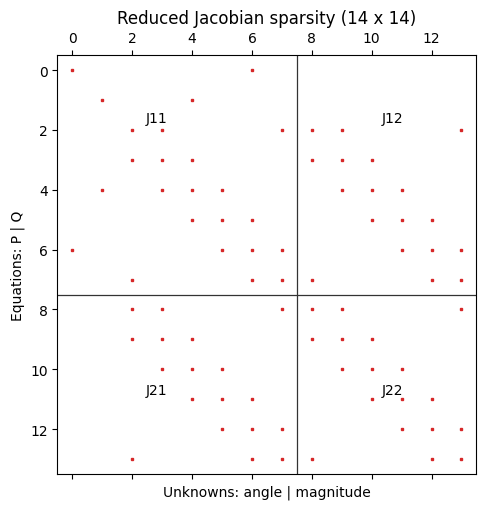

In [5]:
display(tu.jacobian_block_shapes(case))
fig, ax = plt.subplots(figsize=(6, 5.2))
tu.plot_jacobian_block_pattern(case, case.v0, ax)
plt.tight_layout()


**수렴 확인**
- 주석 달린 간소화 구현과 `tutorial_utils.newton_trace`가 같은 수준으로 mismatch를 줄이는지 본다.
- 목적은 모든 구현 세부를 완전히 일치시키는 것이 아니다.
- 목적은 `mismatch -> Jacobian -> solve -> update` 흐름이 실제로 수렴하는 계산이라는 점을 확인하는 것이다.


educational_newton_pf converged=True, iterations=4, final=1.842e-14
tutorial_utils.newton_trace converged=True, iterations=4, final=1.842e-14


,iteration,mismatch_inf_norm
0,0,1.630000e+00
1,1,1.875159e-01
2,2,2.147148e-03
3,3,3.421321e-07
4,4,1.841897e-14


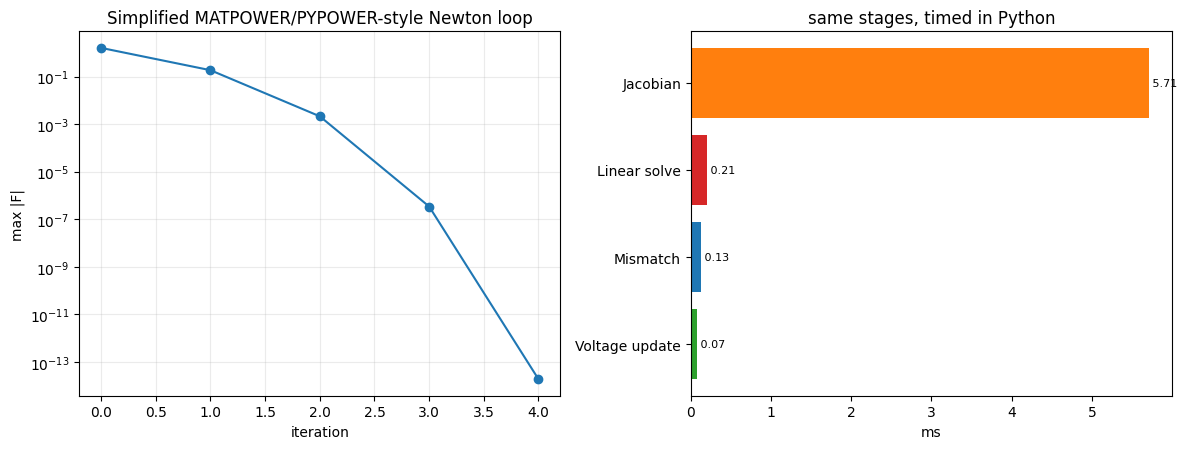

In [6]:
V_simple, simple_trace, converged = educational_newton_pf(case, tol=1e-8, max_it=20)
trace = tu.newton_trace(case, tolerance=1e-8, max_iter=20)
print(f"educational_newton_pf converged={converged}, iterations={len(simple_trace) - 1}, final={simple_trace['mismatch_inf_norm'].iloc[-1]:.3e}")
print(f"tutorial_utils.newton_trace converged={trace.converged}, iterations={trace.iterations}, final={trace.final_mismatch:.3e}")
display(simple_trace)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].semilogy(simple_trace['iteration'], simple_trace['mismatch_inf_norm'], marker='o')
axes[0].set_title('Simplified MATPOWER/PYPOWER-style Newton loop')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('max |F|')
axes[0].grid(True, which='both', alpha=0.25)
tu.plot_stage_timing(trace.stage_totals_ms, axes[1], 'same stages, timed in Python')
plt.tight_layout()


**공통 구조 요약**
```text
V 초기값
  -> mis = S_calc(V) - S_spec
  -> F = [real(mis(PV)), real(mis(PQ)), imag(mis(PQ))]
  -> dSbus_dV(Ybus, V)
  -> J = [[dP/dVa, dP/dVm], [dQ/dVa, dQ/dVm]] reduced blocks
  -> solve J dx = -F
  -> update Va(PV,PQ), Vm(PQ)
  -> repeat until ||F||_inf < tolerance
```

**다음 노트북으로 이어지는 포인트**
- baseline timing은 이 구조의 구현별 비용이다.
- cuPF CPU/GPU 최적화의 기준점은 Jacobian build와 sparse linear solve다.

**참고 자료**
- MATPOWER `newtonpf` reference: https://matpower.org/docs/ref/matpower6.0/newtonpf.html
- MATPOWER `dSbus_dV` reference: https://matpower.org/docs/ref/matpower7.0/lib/dSbus_dV.html
- PYPOWER `newtonpf` source reference: https://rwl.github.io/PYPOWER/api/pypower.newtonpf-pysrc.html
- pandapower overview: https://www.pandapower.org/about/
